In [52]:
import warnings
warnings.filterwarnings('ignore')

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:

# Check available sheet names first
xls = pd.ExcelFile('../data/online_retail_II.xlsx')
print(xls.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [22]:
# Load each sheet into its own DataFrame
df_2009_2010 = pd.read_excel(xls, sheet_name='Year 2009-2010')
df_2010_2011 = pd.read_excel(xls, sheet_name='Year 2010-2011')

In [23]:
# Combine into one DataFrame
df_all = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)
df = df_all.copy()

In [24]:
df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [25]:
df.isna().sum() 

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [26]:
# Let's check how big dataset is.
# .shape gives us (number of rows, number of columns).
print("The dataset has:", df.shape[0], "rows and", df.shape[1], "columns")


The dataset has: 1067371 rows and 8 columns


In [27]:

# List the column names so we know exactly what we have.
print("\nColumns:", list(df.columns))


Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [28]:
# Information in dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


## Data Cleaning

### 1. Fix data types

In [29]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Invoice'] = df['Invoice'].astype(str).str.strip()
df['StockCode'] = df['StockCode'].astype(str).str.strip().str.upper()
df['Description'] = df['Description'].astype(str).str.strip()
df['Country'] = df['Country'].astype(str).str.strip()


### 2. Remove exact duplicate rows

In [30]:
# 2. Remove exact duplicate rows
before = len(df)
df_clean = df.drop_duplicates()
print(f"Dropped {before - len(df_clean)} exact duplicate rows -> {len(df_clean)} left")


Dropped 34335 exact duplicate rows -> 1033036 left


### 3. Drop rows with missing Customer ID

In [31]:
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Customer ID'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
print(f"Dropped {before - len(df_clean)} rows with missing Customer ID -> {len(df_clean)} left")

Dropped 235151 rows with missing Customer ID -> 797885 left


### 4. Drop rows with missing Description

In [32]:
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Description'])
print(f"Dropped {before - len(df_clean)} rows with missing Description -> {len(df_clean)} left")


Dropped 0 rows with missing Description -> 797885 left


### 5. Remove non-product / administrative stock codes

In [33]:
admin_codes = [
    'POST', 'DOT', 'M', 'C2', 'D', 'S', 'BANK CHARGES',
    'ADJUST', 'ADJUST2', 'AMAZONFEE', 'CRUK', 'TEST001', 'TEST002', 'B'
]
before = len(df_clean)
df_clean = df_clean[~df_clean['StockCode'].isin(admin_codes)]
print(f"Dropped {before - len(df_clean)} rows with admin/non-product stock codes -> {len(df_clean)} left")


Dropped 3641 rows with admin/non-product stock codes -> 794244 left


### 6. Separate cancellations (returns) from the sales dataset

Invoices starting with 'C' are cancellations. Keep them in a separate  dataframe in case you want to analyze returns later,
but exclude them  from the "sales" dataset used for RFM/segmentation/prediction.

In [34]:
is_cancelled = df_clean['Invoice'].str.startswith('C')
df_returns = df_clean[is_cancelled].copy()
df_clean = df_clean[~is_cancelled].copy()
print(f"Separated {len(df_returns)} cancelled-order rows into df_returns -> {len(df_clean)} sales rows left")


Separated 17587 cancelled-order rows into df_returns -> 776657 sales rows left


### 7. Remove non-positive quantities and prices
A handful of negative-quantity rows aren't flagged as cancellations , and  zero/negative prices are data errors 
or free/adjustment items with no real revenue signal.

In [35]:
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Dropped {before - len(df_clean)} rows with Quantity <= 0 or Price <= 0 -> {len(df_clean)} left")

Dropped 61 rows with Quantity <= 0 or Price <= 0 -> 776596 left


In [36]:
# -----------------------------------------------------------------------
# 8. Remove extreme price outliers (optional sanity cap)
# -----------------------------------------------------------------------
# A few Price values are in the thousands and clearly not per-unit retail  prices.
#Flag anything beyond the 99.9th percentile for review instead of  silently dropping, so you can decide case by case.
#price_cap = df_clean['Price'].quantile(0.999)
#n_outliers = (df_clean['Price'] > price_cap).sum()
#print(f"{n_outliers} rows have Price above the 99.9th percentile ({price_cap:.2f}) — inspect before deciding to cap/drop")

### 9. Add the Revenue column (needed for EDA/RFM downstream)

In [37]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0


### Final Data cleaning Summary

In [38]:
df_clean = df_clean.reset_index(drop=True)
print("\n==== CLEANING SUMMARY ====")
print(f"Raw rows:        {len(df):,}")
print(f"Clean sales rows:{len(df_clean):,}")
print(f"Returns rows:    {len(df_returns):,}")
print(f"Remaining missing values:\n{df_clean.isna().sum()}")


==== CLEANING SUMMARY ====
Raw rows:        1,067,371
Clean sales rows:776,596
Returns rows:    17,587
Remaining missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64


## Exploratory Data Analysis (EDA)

### Overview of cleaned dataset

In [39]:
print("=== 1. OVERVIEW ===")
print(f"Rows: {df_clean.shape[0]:,} | Columns: {df_clean.shape[1]}")
print(f"Date range: {df_clean['InvoiceDate'].min()} -> {df_clean['InvoiceDate'].max()}")
print("Time span:", df_clean['InvoiceDate'].max() - df_clean['InvoiceDate'].min())
print(f"Unique customers: {df_clean['Customer ID'].nunique():,}")
print(f"Unique invoices: {df_clean['Invoice'].nunique():,}")
print(f"Unique products (StockCode): {df_clean['StockCode'].nunique():,}")
print(f"Unique countries: {df_clean['Country'].nunique()}")

=== 1. OVERVIEW ===
Rows: 776,596 | Columns: 9
Date range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Time span: 738 days 05:05:00
Unique customers: 5,852
Unique invoices: 36,594
Unique products (StockCode): 4,621
Unique countries: 41


### 2. Descriptive statistics


=== 2. DESCRIPTIVE STATISTICS ===
            Quantity          Price        Revenue
count  776596.000000  776596.000000  776596.000000
mean       13.518940       2.934497      21.978716
std       146.094921       4.293580     225.930243
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
75%        12.000000       3.750000      19.800000
max     80995.000000     649.500000  168469.600000


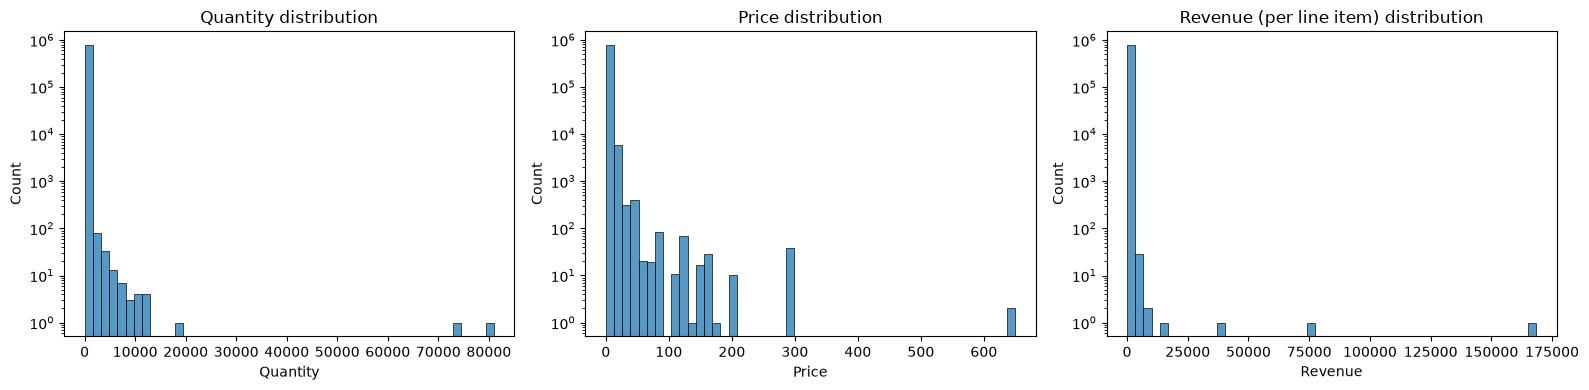

In [42]:
print("\n=== 2. DESCRIPTIVE STATISTICS ===")
print(df_clean[['Quantity', 'Price', 'Revenue']].describe())
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_clean['Quantity'], bins=50, ax=axes[0])
axes[0].set_title('Quantity distribution')
axes[0].set_yscale('log')
 
sns.histplot(df_clean['Price'], bins=50, ax=axes[1])
axes[1].set_title('Price distribution')
axes[1].set_yscale('log')
 
sns.histplot(df_clean['Revenue'], bins=50, ax=axes[2])
axes[2].set_title('Revenue (per line item) distribution')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

### 3. Revenue over time


======================= 3. MONTHLY REVENUE TREND =========================


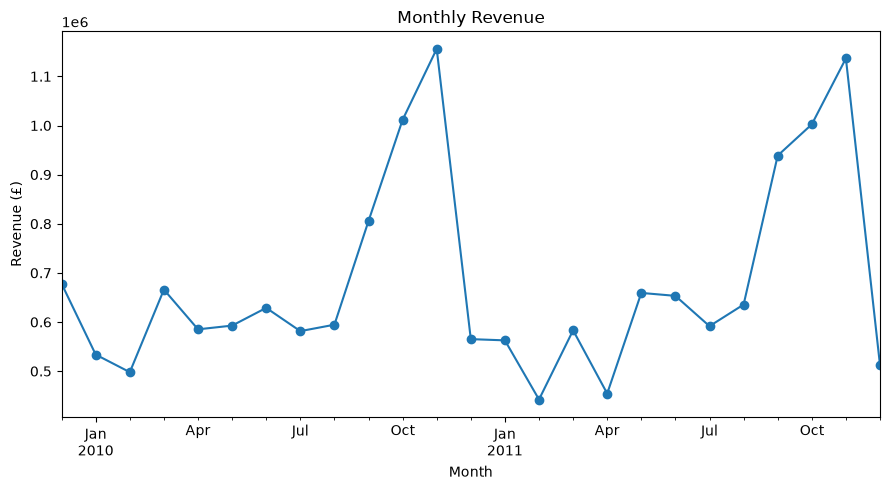

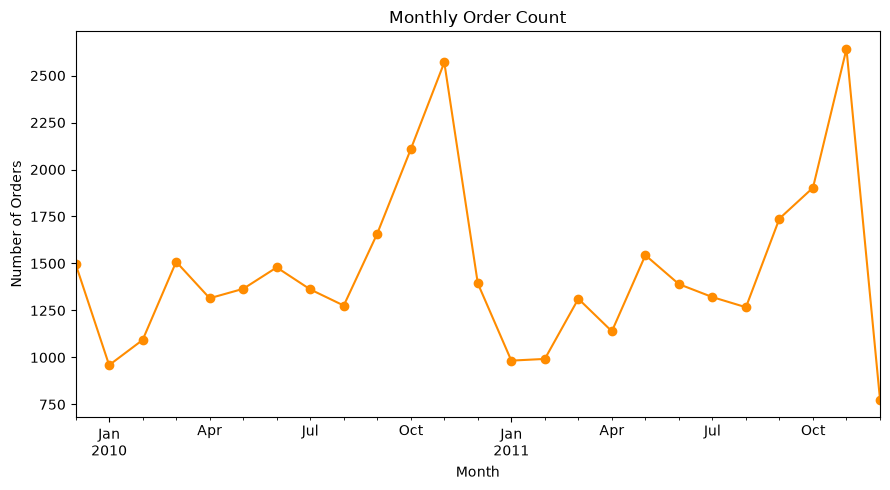

In [43]:
print("\n======================= 3. MONTHLY REVENUE TREND =========================")
monthly_revenue = (
    df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
    .to_timestamp()
)
plt.figure(figsize=(9, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
 
monthly_orders = (
    df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['Invoice']
    .nunique()
    .to_timestamp()
)
plt.figure(figsize=(9, 5))
monthly_orders.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Order Count')
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


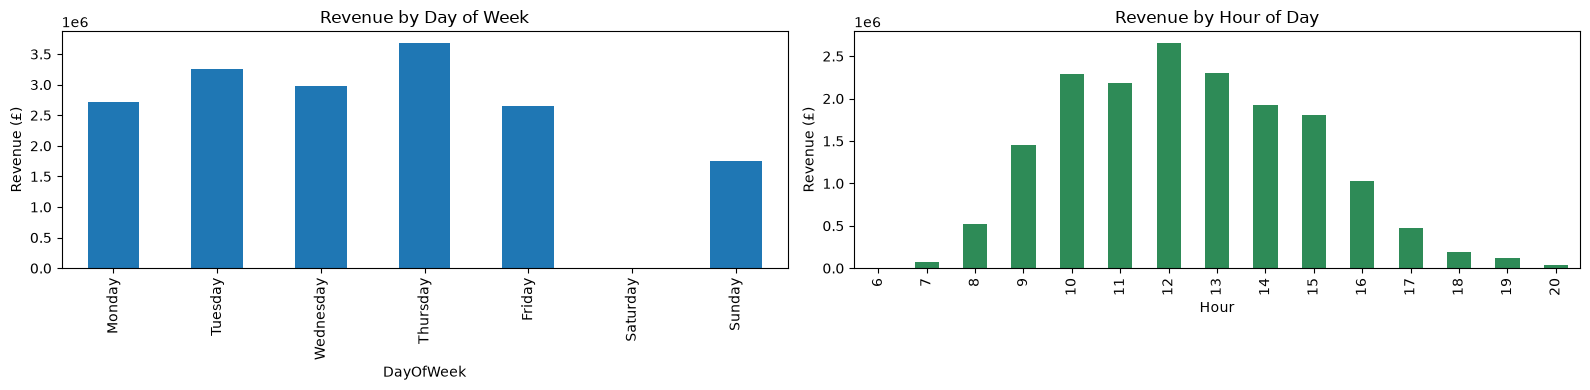

In [44]:
# Day-of-week and hour-of-day patterns
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
 
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
df_clean.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order).plot(kind='bar', ax=axes[0])
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Revenue (£)')
 
df_clean.groupby('Hour')['Revenue'].sum().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()


### Top products


=== 4. TOP PRODUCTS ===
Top 10 by quantity sold:
 Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64

Top 10 by revenue:
 Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               134307.44
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
CHILLI LIGHTS                          69

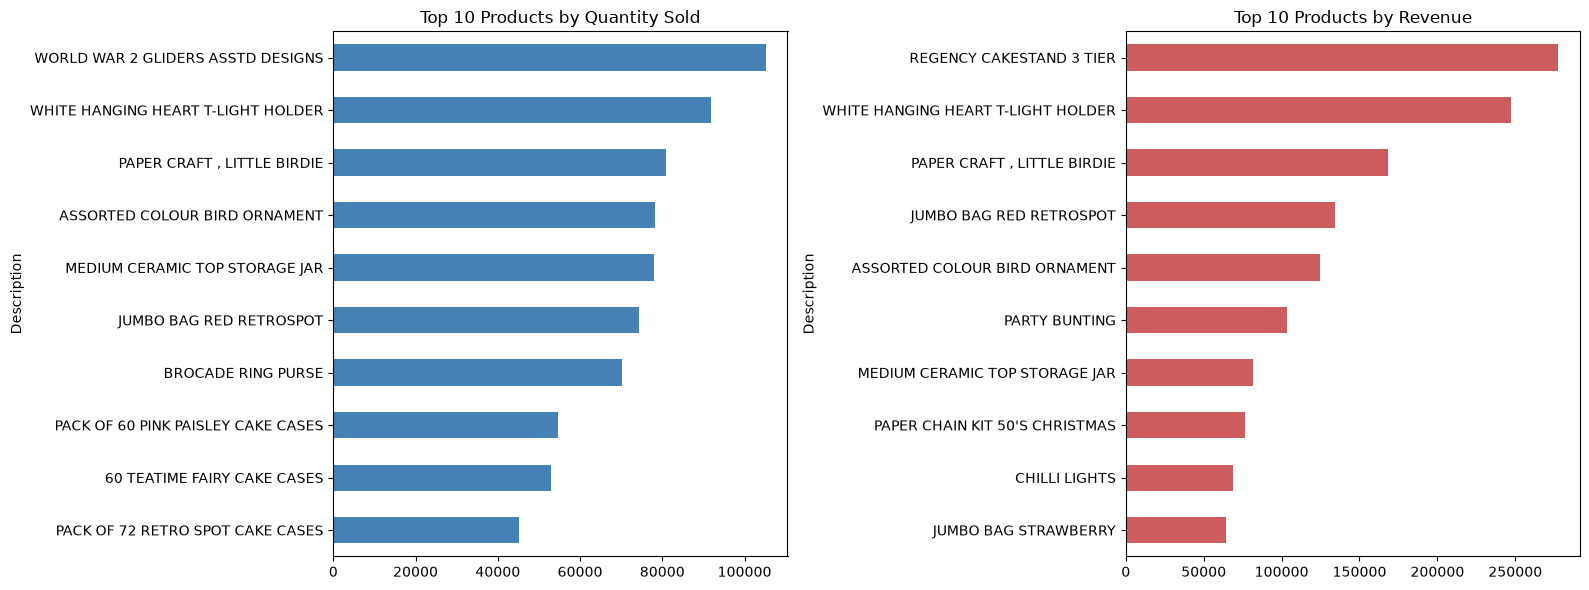

In [45]:
# -----------------------------------------------------------------------
# 4. Top products
# -----------------------------------------------------------------------
print("\n=== 4. TOP PRODUCTS ===")
top_products_qty = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 by quantity sold:\n", top_products_qty)
 
top_products_rev = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 by revenue:\n", top_products_rev)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_products_qty.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Quantity Sold')
 
top_products_rev.sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Top 10 Products by Revenue')
plt.tight_layout()
plt.show()


### 5. Sales by country


=========================== 5. SALES BY COUNTRY ==============================
Top 10 countries by revenue:
 Country
United Kingdom    1.428877e+07
EIRE              5.866261e+05
Netherlands       5.497734e+05
Germany           3.832890e+05
France            3.094032e+05
Australia         1.678000e+05
Spain             9.776675e+04
Switzerland       9.340094e+04
Sweden            8.604514e+04
Denmark           6.742269e+04
Name: Revenue, dtype: float64

Top 10 countries by order count:
 Country
United Kingdom    33361
Germany             753
France              590
EIRE                528
Netherlands         216
Spain               144
Belgium             143
Sweden               98
Australia            89
Portugal             83
Name: Invoice, dtype: int64

UK share of total revenue: 83.7%


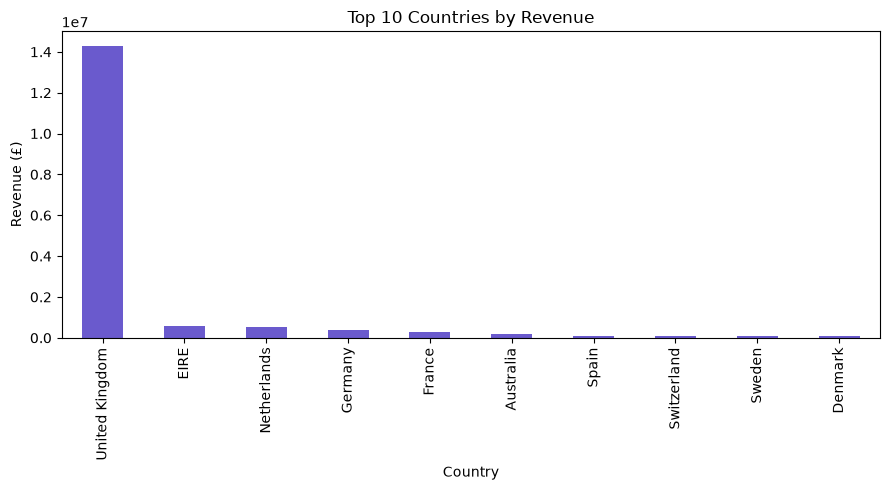

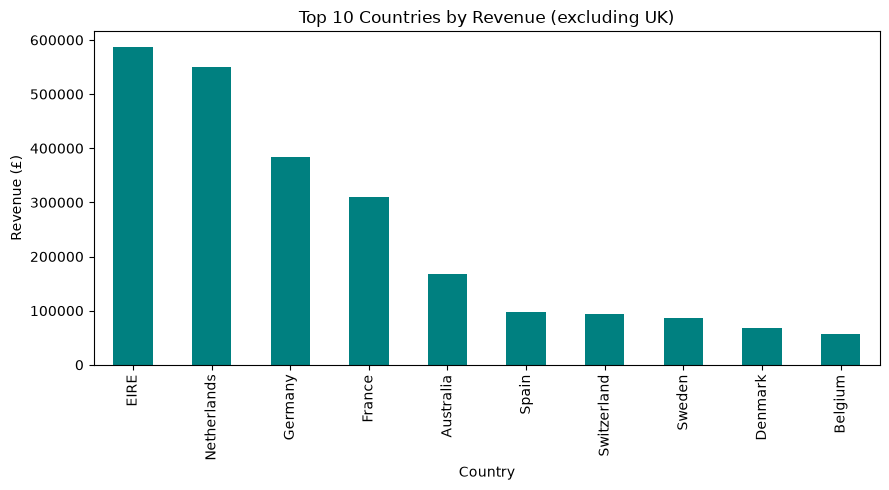

In [46]:
print("\n=========================== 5. SALES BY COUNTRY ==============================")
revenue_by_country = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print("Top 10 countries by revenue:\n", revenue_by_country.head(10))
 
orders_by_country = df_clean.groupby('Country')['Invoice'].nunique().sort_values(ascending=False)
print("\nTop 10 countries by order count:\n", orders_by_country.head(10))
 
# UK dominates volume — show UK vs rest of world, and non-UK detail separately
uk_share = revenue_by_country.get('United Kingdom', 0) / revenue_by_country.sum() * 100
print(f"\nUK share of total revenue: {uk_share:.1f}%")
 
plt.figure(figsize=(9, 5))
revenue_by_country.head(10).plot(kind='bar', color='slateblue')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()
 
plt.figure(figsize=(9, 5))
revenue_by_country.drop('United Kingdom').head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Revenue (excluding UK)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

### 6. Customer-level analysis


======================= 6. CUSTOMER-LEVEL ANALYSIS ================================
Orders per customer:
 count    5852.000000
mean        6.253247
std        12.749286
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       373.000000
Name: Invoice, dtype: float64

Top 10 customers by revenue:
 Customer ID
18102    580987.04
14646    526751.52
14156    303069.88
14911    272252.79
17450    244784.25
13694    195640.69
17511    172132.87
16446    168472.50
16684    147142.77
12415    144033.37
Name: Revenue, dtype: float64


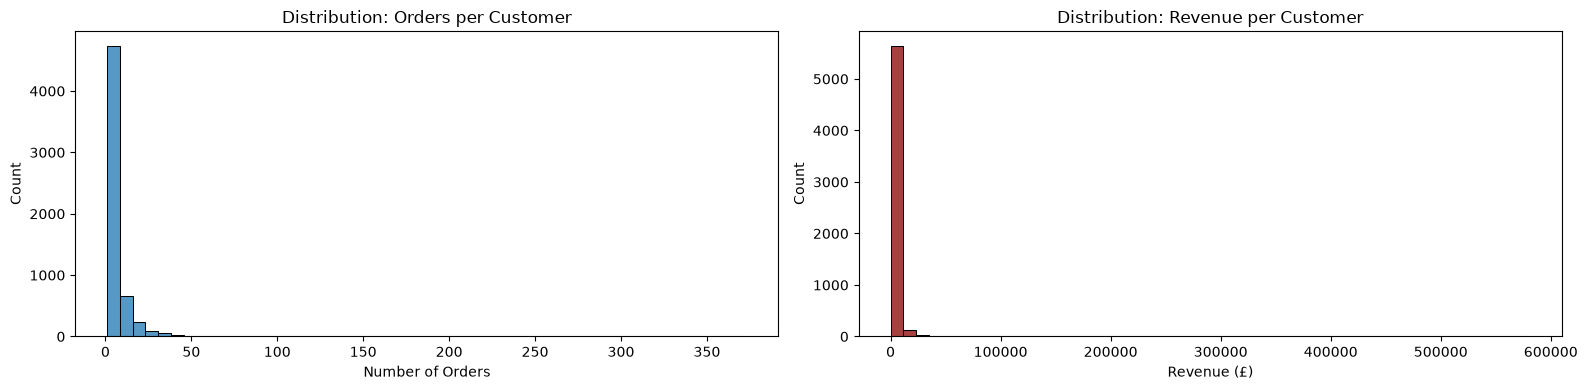


23.1% of customers generate 80% of revenue (1,353 of 5,852 customers)


In [47]:
print("\n======================= 6. CUSTOMER-LEVEL ANALYSIS ================================")
customer_orders = df_clean.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False)
print("Orders per customer:\n", customer_orders.describe())
 
customer_revenue = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
print("\nTop 10 customers by revenue:\n", customer_revenue.head(10))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(customer_orders, bins=50, ax=axes[0])
axes[0].set_title('Distribution: Orders per Customer')
axes[0].set_xlabel('Number of Orders')
 
sns.histplot(customer_revenue, bins=50, ax=axes[1], color='darkred')
axes[1].set_title('Distribution: Revenue per Customer')
axes[1].set_xlabel('Revenue (£)')
plt.tight_layout()
plt.show()
 
# Pareto check: what % of customers drive 80% of revenue?
cum_rev_share = (customer_revenue.sort_values(ascending=False).cumsum() / customer_revenue.sum())
n_customers_for_80pct = (cum_rev_share <= 0.80).sum() + 1
pct_customers_for_80pct = n_customers_for_80pct / len(customer_revenue) * 100
print(f"\n{pct_customers_for_80pct:.1f}% of customers generate 80% of revenue "
      f"({n_customers_for_80pct:,} of {len(customer_revenue):,} customers)")


### 7. Basket size


============================== 7. BASKET SIZE (items and value per order) ========================
       ItemsPerBasket  LineItemsPerBasket    BasketValue
count    36594.000000        36594.000000   36594.000000
mean       286.898262           20.935071     466.431184
std       1238.200570           22.404017    1358.869318
min          1.000000            1.000000       0.380000
25%         74.000000            7.000000     158.630000
50%        153.000000           15.000000     302.550000
75%        288.000000           27.000000     473.880000
max      87167.000000          540.000000  168469.600000


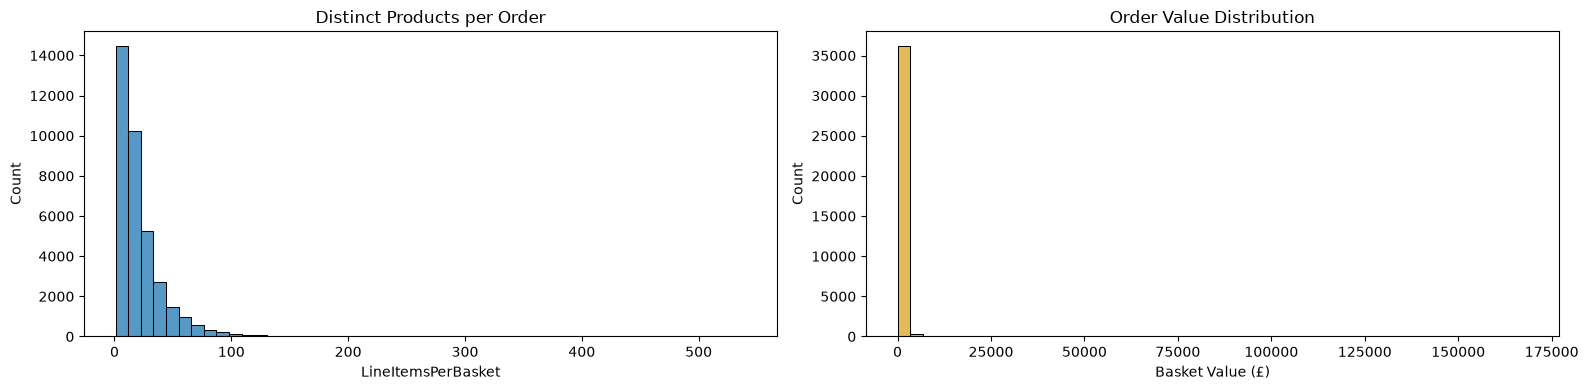

In [48]:
print("\n============================== 7. BASKET SIZE (items and value per order) ========================")
basket = df_clean.groupby('Invoice').agg(
    ItemsPerBasket=('Quantity', 'sum'),
    LineItemsPerBasket=('StockCode', 'nunique'),
    BasketValue=('Revenue', 'sum')
)
print(basket.describe())
 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(basket['LineItemsPerBasket'], bins=50, ax=axes[0])
axes[0].set_title('Distinct Products per Order')
 
sns.histplot(basket['BasketValue'], bins=50, ax=axes[1], color='goldenrod')
axes[1].set_title('Order Value Distribution')
axes[1].set_xlabel('Basket Value (£)')
plt.tight_layout()
plt.show()

### 8. Returns exploration (df_returns, set aside during cleaning)

In [49]:
print("\n========================== 8. RETURNS / CANCELLATIONS ==============================")
print(f"Cancelled-order lines: {len(df_returns):,}")
print(f"Cancelled invoices: {df_returns['Invoice'].nunique():,} "
      f"({df_returns['Invoice'].nunique() / df_clean['Invoice'].nunique() * 100:.1f}% of sales invoice count)")
 
returns_by_country = df_returns.groupby('Country')['Invoice'].nunique().sort_values(ascending=False)
print("\nTop 5 countries by number of cancelled invoices:\n", returns_by_country.head(5))



========================== 8. RETURNS / CANCELLATIONS ==============================
Cancelled-order lines: 17,587
Cancelled invoices: 7,283 (19.9% of sales invoice count)

Top 5 countries by number of cancelled invoices:
 Country
United Kingdom    6492
Germany            282
EIRE               133
France             111
Belgium             29
Name: Invoice, dtype: int64


### 9. Correlation check


========================== 9. CORRELATIONS ===============================
          Quantity     Price   Revenue
Quantity  1.000000 -0.028206  0.834347
Price    -0.028206  1.000000  0.060962
Revenue   0.834347  0.060962  1.000000


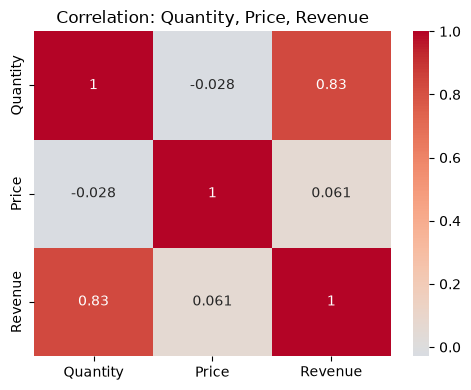

In [50]:
print("\n========================== 9. CORRELATIONS ===============================")
corr = df_clean[['Quantity', 'Price', 'Revenue']].corr()
print(corr)
 
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Quantity, Price, Revenue')
plt.tight_layout()
plt.show()
